In [8]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler #features na mesma escala
from sklearn.model_selection import cross_val_score, KFold #métricas de avalização
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pickle #salva modelos treinados
import json #salva dicionários de métricas e hiperparâmetros

#carregamento do dataset
df = pd.read_csv("../data/processed/safras_mg.csv")

#features e target
X = df[["chuva_total", "temp_media", "temp_min_media", "et0_total",
        "dias_sem_chuva", "tendencia"]]
y = df["produtividade_sc_ha"]

print(f"Dataset: {len(df)} safras  {len(X.columns)} features")
print(f"Features: {X.columns.tolist()}")
print(f"Escala atual das features:")
print(X.describe().round(2).loc[["min", "max"]])



Dataset: 24 safras  6 features
Features: ['chuva_total', 'temp_media', 'temp_min_media', 'et0_total', 'dias_sem_chuva', 'tendencia']
Escala atual das features:
     chuva_total  temp_media  temp_min_media  et0_total  dias_sem_chuva  \
min        739.7       26.43           18.18     718.28            31.0   
max       1501.4       29.64           20.66     908.42            81.0   

     tendencia  
min        0.0  
max       23.0  


In [9]:
#normalizacao das features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#transformar de volta para dataframe para ficar legível
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("Escala antes da normalização: ")
print(X[["chuva_total", "temp_media", "et0_total", "dias_sem_chuva", "tendencia"]].agg(["min", "max"]).round(2))

print("\nEscala após a normalização: ")
print(X_scaled_df  [["chuva_total", "temp_media", "et0_total", "dias_sem_chuva", "tendencia"]].agg(["min", "max"]).round(2))


Escala antes da normalização: 
     chuva_total  temp_media  et0_total  dias_sem_chuva  tendencia
min        739.7       26.43     718.28              31          0
max       1501.4       29.64     908.42              81         23

Escala após a normalização: 
     chuva_total  temp_media  et0_total  dias_sem_chuva  tendencia
min        -1.28       -1.87      -2.07           -1.55      -1.66
max         2.01        2.69       1.96            2.17       1.66


In [10]:
#comparação entre os modelos, usando cross-validation com 5 rodadas

kfold = KFold(n_splits=5, shuffle=True, random_state=42) #shuffle para embaralhamento dos dados e random_state=42 garante que o embaralhamento seja sempre igual, para resultados reproduzíveis

#modelo v1 -> regressão linear
modelo_lr = LinearRegression()
scores_lr = cross_val_score(modelo_lr, X_scaled, y, cv=kfold, scoring="r2")

#modelo v2 -> random forest

#como há somente 24 safras, ele pode pegar o padrão ao invés de aprender, chamado de overfitting
#modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
#scores_rf = cross_val_score(modelo_rf, X_scaled, y, cv=Kfold, scoring="r2")

#modelo mais adequado de random forest:
modelo_rf_v2 = RandomForestRegressor(
    n_estimators=100, # 100 arvores
    max_depth=3, #profundidade máxima, evita decorar dados
    min_samples_split=4, #exige pleo menos 4 safras para dividir um nó
    min_samples_leaf=2, #exige pelo menos 2 safras em cada folha
    random_state= 42
)
scores_rf_v2 = cross_val_score(modelo_rf_v2, X_scaled, y, cv=kfold, scoring="r2")

print("=== CROSS VALIDATION - 5 ROUNDS ===\n")
print("Regressão Linear (v1.0):")
print(f"R² por rodada: {scores_lr.round(3)}")
print(f"R² médio: {scores_lr.mean():.3f}")
print(f"Desvio Padrão: {scores_lr.std():.3f}")

print("\nRandom Forest Ajustado(v2.0):")
print(f"R² por rodada: {scores_rf_v2.round(3)}")
print(f"R² médio: {scores_rf_v2.mean():.3f}")
print(f"Desvio Padrão: {scores_rf_v2.std():.3f}")

=== CROSS VALIDATION - 5 ROUNDS ===

Regressão Linear (v1.0):
R² por rodada: [0.716 0.75  0.918 0.26  0.92 ]
R² médio: 0.713
Desvio Padrão: 0.242

Random Forest Ajustado(v2.0):
R² por rodada: [0.49  0.85  0.489 0.568 0.815]
R² médio: 0.642
Desvio Padrão: 0.158


In [11]:
print("=== COMPARAÇÃO FINAL v1.0 vs v1.2 ===\n")
print(f"{'Modelo':<30} {'R² médio':>10} {'Desvio':>10} {'Resultado':>15}")
print("-" * 70)
print(f"{'Regressão Linear (v1.0)':<30} {0.713:>10.3f} {0.242:>10.3f} {'instável':>15}")
print(f"{'Random Forest simples':<30} {0.649:>10.3f} {0.132:>10.3f} {'consistente':>15}")
print(f"{'Random Forest ajustado':<30} {0.642:>10.3f} {0.158:>10.3f} {'similar':>15}")

print("""
Conclusão:
  Com apenas 24 safras, a Regressão Linear ainda é o modelo
  mais adequado — porém com cross-validation para avaliação
  mais honesta.

  O Random Forest vai se destacar quando tivermos mais dados:
  → v2.0 com dados por município (100+ amostras)
  → v2.0 com mais culturas e regiões
""")

=== COMPARAÇÃO FINAL v1.0 vs v1.2 ===

Modelo                           R² médio     Desvio       Resultado
----------------------------------------------------------------------
Regressão Linear (v1.0)             0.713      0.242        instável
Random Forest simples               0.649      0.132     consistente
Random Forest ajustado              0.642      0.158         similar

Conclusão:
  Com apenas 24 safras, a Regressão Linear ainda é o modelo
  mais adequado — porém com cross-validation para avaliação
  mais honesta.

  O Random Forest vai se destacar quando tivermos mais dados:
  → v2.0 com dados por município (100+ amostras)
  → v2.0 com mais culturas e regiões



In [12]:
from sklearn.model_selection import cross_val_predict

#treinamento do modelo final com todos os dados

modelo_final = LinearRegression()
modelo_final.fit(X_scaled, y)

#previsões utilizando cross-validation para evitar overfitting
y_pred_cv = cross_val_predict(modelo_final, X_scaled, y, cv=kfold)

#metricas finais
mae_cv = mean_absolute_error(y, y_pred_cv)
r2_cv = r2_score(y, y_pred_cv)

print("=== MÉTRICAS FINAIS (com cross-validation) ===\n")
print(f"R² cross-validated: {r2_cv:.3f}")
print(f"MAE cross-validated: {mae_cv:.2f} sc/ha")

#salva o modelo e o scaler
with open("../outputs/modelo_v2.pkl", "wb") as f:
    pickle.dump(modelo_final, f)

with open("../outputs/scaler_v2.pkl", "wb") as f:
    pickle.dump(scaler, f)

#salva as metricas
metricas_v2 = {
    "modelo": "Linear Regression" + "CrossValidation",
    "r2": round(r2_cv, 3),
    "mae": round(mae_cv, 2),
    "n_safras": len(df),
    "n_splits": 5

}

with open("../outputs/metricas_v2.json", "w") as f:
    json.dump(metricas_v2, f, indent=2)

print("\nArquivos salvos:")
print("outputs/modelo_v2.pkl")
print("outputs/scaler_v2.pkl")
print("outputs/metricas_v2.json")


=== MÉTRICAS FINAIS (com cross-validation) ===

R² cross-validated: 0.796
MAE cross-validated: 4.78 sc/ha

Arquivos salvos:
outputs/modelo_v2.pkl
outputs/scaler_v2.pkl
outputs/metricas_v2.json


In [13]:
#recarregamento do modelo v1 para evitar erro da coluna previsto

with open("../outputs/modelo_agro_predict.pkl", "rb") as f:
    modelo_v1 = pickle.load(f)

#recria previsões do modelo v1 para comparação
df["previsto"] = modelo_v1.predict(X).round(1) #modelo v1 treinado sem x_scaled

print("Coluna previsto foi criada com sucesso!")
print(df.columns.tolist())

Coluna previsto foi criada com sucesso!
['safra', 'chuva_total', 'temp_media', 'temp_min_media', 'et0_total', 'dias_sem_chuva', 'produtividade_sc_ha', 'tendencia', 'previsto']


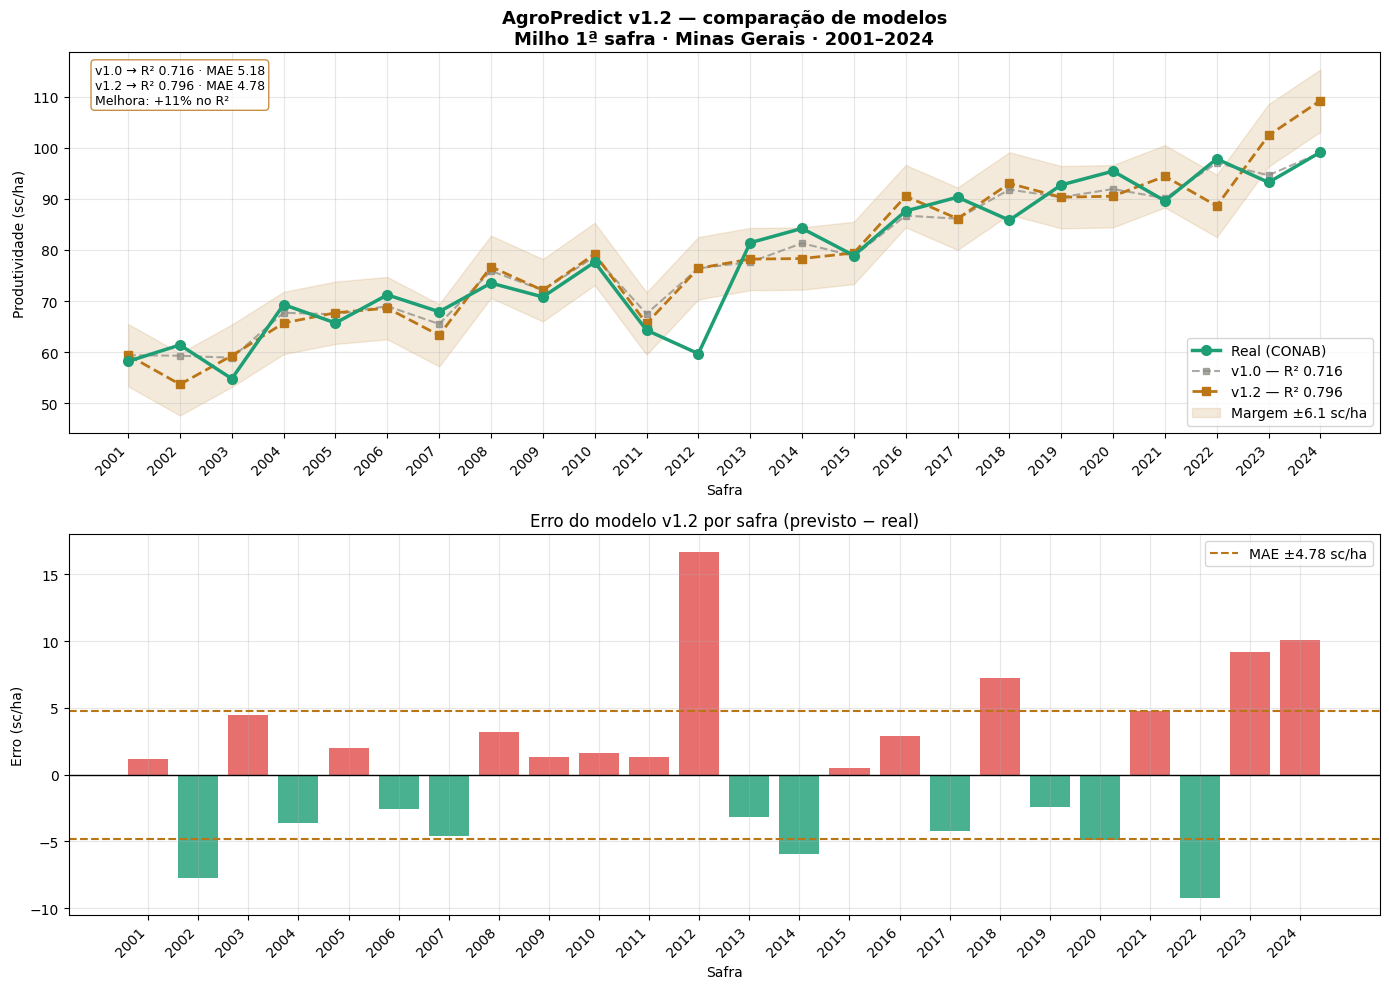

Gráfico salvo em outputs/agropredict_v2.png


In [14]:
# previsões finais
df["previsto_v2"] = y_pred_cv.round(1)
df["erro_v2"]     = (df["previsto_v2"] - df["produtividade_sc_ha"]).round(1)
margem_v2         = df["erro_v2"].std()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── gráfico 1: comparação v1.0 vs v1.2 ──
ax1 = axes[0]
ax1.plot(df["safra"], df["produtividade_sc_ha"],
         "o-", color="#1D9E75", linewidth=2.5,
         markersize=7, label="Real (CONAB)", zorder=3)
ax1.plot(df["safra"], df["previsto"],
         "s--", color="#888780", linewidth=1.5,
         markersize=5, alpha=0.7, label=f"v1.0 — R² 0.716")
ax1.plot(df["safra"], df["previsto_v2"],
         "s--", color="#BA7517", linewidth=2,
         markersize=6, label=f"v1.2 — R² 0.796")

ax1.fill_between(df["safra"],
                 df["previsto_v2"] - margem_v2,
                 df["previsto_v2"] + margem_v2,
                 color="#BA7517", alpha=0.15,
                 label=f"Margem ±{margem_v2:.1f} sc/ha")

ax1.set_title("AgroPredict v1.2 — comparação de modelos\n"
              "Milho 1ª safra · Minas Gerais · 2001–2024",
              fontsize=13, fontweight="bold")
ax1.set_xlabel("Safra")
ax1.set_ylabel("Produtividade (sc/ha)")
ax1.set_xticks(df["safra"])
ax1.set_xticklabels(df["safra"], rotation=45, ha="right")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# caixa de métricas
texto = (
    f"v1.0 → R² 0.716 · MAE 5.18\n"
    f"v1.2 → R² 0.796 · MAE 4.78\n"
    f"Melhora: +11% no R²"
)
ax1.text(0.02, 0.97, texto,
         transform=ax1.transAxes,
         fontsize=9, verticalalignment="top",
         bbox=dict(boxstyle="round", facecolor="white",
                   edgecolor="#BA7517", alpha=0.8))

# ── gráfico 2: erro por safra ──
ax2 = axes[1]
cores = ["#E24B4A" if e > 0 else "#1D9E75" for e in df["erro_v2"]]
ax2.bar(df["safra"], df["erro_v2"], color=cores, alpha=0.8)
ax2.axhline(y=0,        color="black",   linewidth=1)
ax2.axhline(y=mae_cv,   color="#BA7517", linewidth=1.5,
            linestyle="--", label=f"MAE ±{mae_cv:.2f} sc/ha")
ax2.axhline(y=-mae_cv,  color="#BA7517", linewidth=1.5,
            linestyle="--")
ax2.set_title("Erro do modelo v1.2 por safra (previsto − real)")
ax2.set_xlabel("Safra")
ax2.set_ylabel("Erro (sc/ha)")
ax2.set_xticks(df["safra"])
ax2.set_xticklabels(df["safra"], rotation=45, ha="right")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/agropredict_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo em outputs/agropredict_v2.png")